<a href="https://colab.research.google.com/github/esma-celikten/musteri-sadakati-tahmini/blob/main/Eticaret_analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Kütüphaneler başarıyla yüklendi!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

Kütüphaneler başarıyla yüklendi!
Pandas: 2.2.2
Numpy: 2.0.2


Pandas, numpy , matplotlib kütüpaneleri yüklendi.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)  # Aynı sonuçları tekrar üretmek için
n = 1000            # Kayıt sayısı

# Değişkenleri oluştur
df = pd.DataFrame({
    'Yaş': np.random.randint(15, 85, n),
    'Cinsiyet': np.random.choice(['Kadın', 'Erkek'], n),
    'Şehir': np.random.choice(['İstanbul', 'Ankara', 'İzmir', 'Bursa', 'Antalya', 'Nevşehir', 'Kayseri', 'Bolu', 'Manisa', 'Giresun', 'Trabzon', 'Bursa', 'Ordu', 'Adana', 'Gaziantep', 'Kars', 'Erzurum', 'Eskişehir', 'Mersin', 'Muğla' ], n),

    'Kategori': np.random.choice(['Elektronik', 'Giyim', 'Kozmetik', 'Mobilya', 'Beyaz Eşya', 'Kırtasiye', 'Otomobil', 'Spor', 'Kitap'],n,p=[0.22, 0.20, 0.16, 0.12, 0.10, 0.08, 0.06, 0.03, 0.03]),
    'Ödeme_Yöntemi': np.random.choice(['Kredi Kartı', 'Banka Kartı', 'Kapıda Nakit Ödeme', 'Kapıda Kartla Ödeme', 'Havale'], n,p=[0.42, 0.09, 0.11, 0.24, 0.14]),
    'Üyelik_Süresi_Ay': np.random.randint(1, 60, n),
    'Önceki_Satın_Alma': np.random.randint(0, 20, n),
    'İndirim_Oranı': np.random.choice([0, 10, 20, 30], n),

    'İade_Sayısı': np.random.randint(0, 5, n),
    'Müşteri_Skoru': np.random.randint(1, 6, n),
})

fiyat_aralik = {
    'Kitap': (50, 500),
    'Kozmetik': (100, 2000),
    'Giyim': (100, 5000),
    'Spor': (200, 10000),
    'Elektronik': (500, 50000),
    'Mobilya': (1000, 80000),
    'Beyaz Eşya': (2000, 60000),
    'Kırtasiye': (20, 500),
    'Otomobil': (200000, 500000)
}


df['Fiyat'] = df['Kategori'].apply(
    lambda k: np.random.randint(fiyat_aralik[k][0], fiyat_aralik[k][1])
)
print(df.groupby('Kategori')['Fiyat'].mean().round(0))

# Hedef değişken: Tekrar satın alma (0 = Hayır, 1 = Evet)
df['Tekrar_Satın_Alma'] = (
    (df['Önceki_Satın_Alma'] > 5).astype(int) +
    (df['Müşteri_Skoru'] >= 4).astype(int) +
    (df['İndirim_Oranı'] >= 20).astype(int) +
    (df['İade_Sayısı'] < 2).astype(int)
)
df['Tekrar_Satın_Alma'] = (
    (df['Önceki_Satın_Alma'] > 10).astype(int) +
    (df['Müşteri_Skoru'] >= 4).astype(int) +
    (df['İndirim_Oranı'] >= 20).astype(int) +
    (df['İade_Sayısı'] < 2).astype(int) +
    (df['Üyelik_Süresi_Ay'] > 30).astype(int)
)
df['Tekrar_Satın_Alma'] = (df['Tekrar_Satın_Alma'] >= 3).astype(int)

print(df.shape)
print(df.head())
# Excel dosyasına kaydet
df.to_excel('eticaret_veri.xlsx', index=False)

# Google Colab'dan bilgisayarına indir
from google.colab import files
files.download('eticaret_veri.xlsx')

Kategori
Beyaz Eşya     31440.0
Elektronik     23983.0
Giyim           2585.0
Kitap            283.0
Kozmetik        1135.0
Kırtasiye        241.0
Mobilya        39723.0
Otomobil      354207.0
Spor            4290.0
Name: Fiyat, dtype: float64
(1000, 12)
   Yaş Cinsiyet     Şehir    Kategori        Ödeme_Yöntemi  Üyelik_Süresi_Ay  \
0   66    Erkek     Bursa  Elektronik  Kapıda Kartla Ödeme                42   
1   29    Kadın  İstanbul  Beyaz Eşya  Kapıda Kartla Ödeme                26   
2   75    Kadın     Muğla    Otomobil  Kapıda Kartla Ödeme                48   
3   35    Kadın   Trabzon       Giyim  Kapıda Kartla Ödeme                51   
4   38    Kadın   Antalya   Kırtasiye  Kapıda Kartla Ödeme                26   

   Önceki_Satın_Alma  İndirim_Oranı  İade_Sayısı  Müşteri_Skoru   Fiyat  \
0                  3             20            0              3   36831   
1                  5             10            1              4   22968   
2                 15             30    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Veri oluşturuldu

In [ ]:
print(df['Ödeme_Yöntemi'].value_counts())

Ödeme_Yöntemi
Kredi Kartı            439
Kapıda Kartla Ödeme    252
Havale                 121
Kapıda Nakit Ödeme     111
Banka Kartı             77
Name: count, dtype: int64


In [ ]:
print("Veri boyutu:", df.shape)
print("\nŞehirler:", df['Şehir'].unique())
print("\nKategoriler:", df['Kategori'].unique())
print("\nYaş aralığı:", df['Yaş'].min(), "-", df['Yaş'].max())

Veri boyutu: (1000, 12)

Şehirler: ['Bursa' 'İstanbul' 'Muğla' 'Trabzon' 'Antalya' 'Gaziantep' 'Erzurum'
 'Nevşehir' 'Eskişehir' 'Adana' 'Ankara' 'Manisa' 'İzmir' 'Mersin'
 'Giresun' 'Kayseri' 'Ordu' 'Kars' 'Bolu']

Kategoriler: ['Elektronik' 'Beyaz Eşya' 'Otomobil' 'Giyim' 'Kırtasiye' 'Spor'
 'Kozmetik' 'Mobilya' 'Kitap']

Yaş aralığı: 15 - 84


In [ ]:
# Verinin genel özeti
print("=== VERİ BOYUTU ===")
print(f"Satır sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")

print("\n=== İLK 5 SATIR ===")
print(df.head())

print("\n=== SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ ===")
print(df.describe())

print("\n=== EKSİK DEĞER KONTROLÜ ===")
print(df.isnull().sum())

=== VERİ BOYUTU ===
Satır sayısı: 741
Sütun sayısı: 42

=== İLK 5 SATIR ===
   Yaş  Cinsiyet  Üyelik_Süresi_Ay  Önceki_Satın_Alma  İndirim_Oranı  \
0   66         0                42                  3             20   
1   29         1                26                  5             10   
3   35         1                51                  1             10   
4   38         1                26                 17             10   
6   36         0                43                 16              0   

   İade_Sayısı  Müşteri_Skoru   Fiyat  Tekrar_Satın_Alma  Şehir_Adana  ...  \
0            0              3   36831                  1        False  ...   
1            1              4   22968                  0        False  ...   
3            0              5    3200                  1        False  ...   
4            1              2      58                  0        False  ...   
6            1              2  284193                  1        False  ...   

   Kategori_Kozmetik  

In [ ]:
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


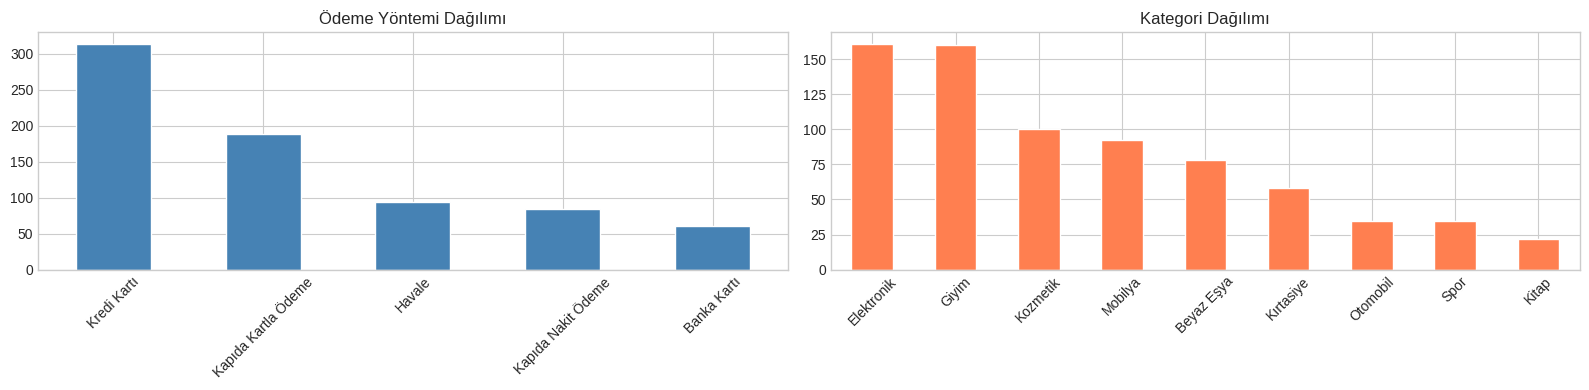

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik stilini ayarla
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Grafik 1: Ödeme Yöntemi Dağılımı
df['Ödeme_Yöntemi'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Ödeme Yöntemi Dağılımı')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Grafik 2: Kategori Dağılımı
df['Kategori'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Kategori Dağılımı')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

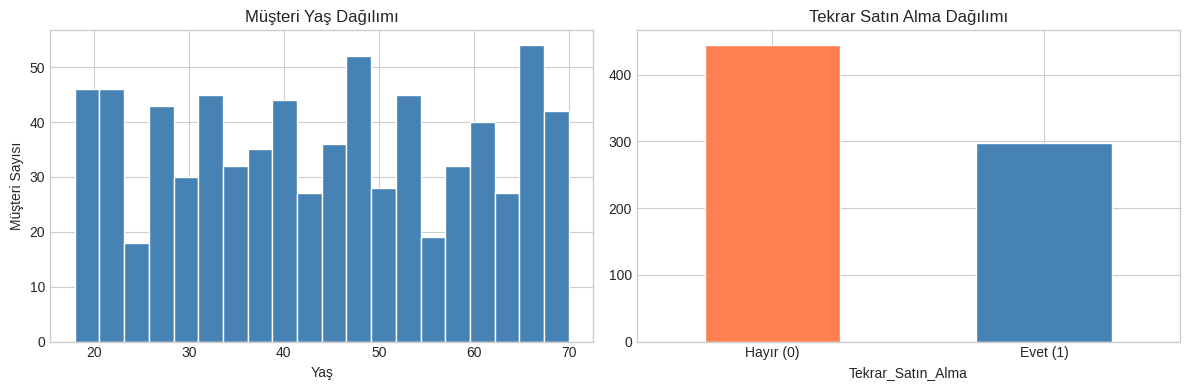

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafik 1: Yaş dağılımı
axes[0].hist(df['Yaş'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Müşteri Yaş Dağılımı')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Müşteri Sayısı')

# Grafik 2: Tekrar satın alma dağılımı
df['Tekrar_Satın_Alma'].value_counts().plot(
    kind='bar', ax=axes[1], color=['coral', 'steelblue'], edgecolor='white'
)
axes[1].set_title('Tekrar Satın Alma Dağılımı')
axes[1].set_xticklabels(['Hayır (0)', 'Evet (1)'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print(df['Tekrar_Satın_Alma'].value_counts())
print("\nYüzdelik Dağılım:")
print(df['Tekrar_Satın_Alma'].value_counts(normalize=True).round(2) * 100)

Tekrar_Satın_Alma
0    444
1    297
Name: count, dtype: int64

Yüzdelik Dağılım:
Tekrar_Satın_Alma
0    60.0
1    40.0
Name: proportion, dtype: float64


In [ ]:
sayisal_kolonlar = ['Yaş', 'Üyelik_Süresi_Ay', 'Önceki_Satın_Alma',
                    'İndirim_Oranı', 'Fiyat', 'İade_Sayısı',
                    'Müşteri_Skoru', 'Tekrar_Satın_Alma']

korelasyon = df[sayisal_kolonlar].corr()

print("=== KORELASYON MATRİSİ ===")
print(korelasyon.round(2))

print("\n=== TEKRAR SATIN ALMA İLE EN YÜKSEK İLİŞKİLİ DEĞİŞKENLER ===")
print(korelasyon['Tekrar_Satın_Alma'].sort_values(ascending=False).round(2))

=== KORELASYON MATRİSİ ===
                    Yaş  Üyelik_Süresi_Ay  Önceki_Satın_Alma  İndirim_Oranı  \
Yaş                1.00             -0.01               0.02           0.04   
Üyelik_Süresi_Ay  -0.01              1.00              -0.01           0.04   
Önceki_Satın_Alma  0.02             -0.01               1.00          -0.01   
İndirim_Oranı      0.04              0.04              -0.01           1.00   
Fiyat              0.06              0.02              -0.08          -0.02   
İade_Sayısı        0.02              0.01               0.03          -0.00   
Müşteri_Skoru      0.05              0.02              -0.03           0.00   
Tekrar_Satın_Alma  0.04              0.35               0.34           0.33   

                   Fiyat  İade_Sayısı  Müşteri_Skoru  Tekrar_Satın_Alma  
Yaş                 0.06         0.02           0.05               0.04  
Üyelik_Süresi_Ay    0.02         0.01           0.02               0.35  
Önceki_Satın_Alma  -0.08         0.03  

Uzun süredir üye → sadık müşteri → tekrar alır ✅
İndirim gördü → memnun → tekrar alır ✅
Çok iade yaptı → memnun değil → gelmez ✅
Yaşın etkisi yok → her yaştan müşteri alışveriş yapabilir ✅

"Korelasyon analizine göre tekrar satın almayı en çok etkileyen faktörler üyelik süresi, indirim oranı ve geçmiş satın alma sayısıdır. İade sayısı ise tek negatif etkili değişken olarak öne çıkmaktadır."

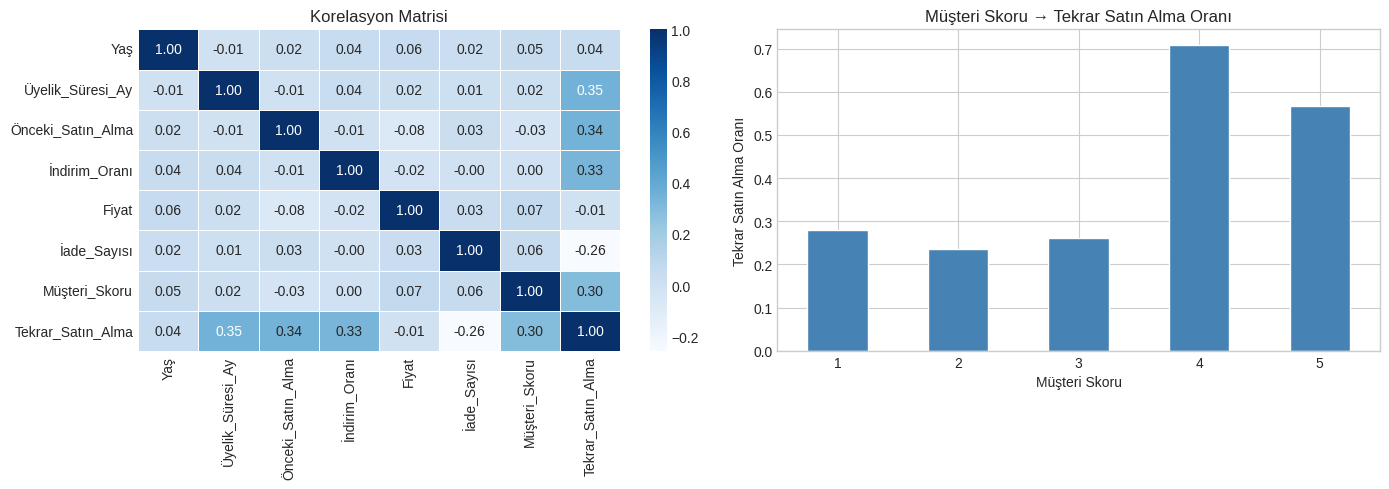

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Korelasyon Matrisi
sayisal_kolonlar = ['Yaş', 'Üyelik_Süresi_Ay', 'Önceki_Satın_Alma',
                    'İndirim_Oranı', 'Fiyat', 'İade_Sayısı',
                    'Müşteri_Skoru', 'Tekrar_Satın_Alma']

korelasyon = df[sayisal_kolonlar].corr()

sns.heatmap(korelasyon,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Korelasyon Matrisi')

# Grafik 2: Müşteri Skoru vs Tekrar Satın Alma
df.groupby('Müşteri_Skoru')['Tekrar_Satın_Alma'].mean().plot(
    kind='bar',
    ax=axes[1],
    color='steelblue',
    edgecolor='white'
)
axes[1].set_title('Müşteri Skoru → Tekrar Satın Alma Oranı')
axes[1].set_xlabel('Müşteri Skoru')
axes[1].set_ylabel('Tekrar Satın Alma Oranı')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print("=== TEMİZLEME ÖNCESİ ===")
print(f"Satır sayısı: {df.shape[0]}")
print(f"Yaş aralığı: {df['Yaş'].min()} - {df['Yaş'].max()}")

=== TEMİZLEME ÖNCESİ ===
Satır sayısı: 741
Yaş aralığı: 18 - 70


Temizleme işleminden önce yedekleme yapalım.*** df_yedek = df.copy()***

In [ ]:
df_yedek = df.copy()

In [ ]:
print("=== YAŞ GRUPLARINA GÖRE DAĞILIM ===")
print(f"15-17 arası: {len(df[df['Yaş'] < 18])} kişi")
print(f"18-66 arası: {len(df[(df['Yaş'] >= 18) & (df['Yaş'] <= 66)])} kişi")
print(f"67-70 arası: {len(df[(df['Yaş'] > 66) & (df['Yaş'] <= 70)])} kişi")
print(f"71-84 arası: {len(df[df['Yaş'] > 70])} kişi")

=== YAŞ GRUPLARINA GÖRE DAĞILIM ===
15-17 arası: 0 kişi
18-66 arası: 685 kişi
67-70 arası: 56 kişi
71-84 arası: 0 kişi


15-17 yaş arası reşit olmayan kullanıcılar ve 70 yaş üstü e-ticaret kullanımı düşük segment veri setinden çıkarılmıştır."

In [ ]:
# 18 yaşından küçük ve 70 yaşından büyükleri çıkar
df = df[(df['Yaş'] >= 18) & (df['Yaş'] <= 70)]

print("=== YAŞ TEMİZLEME SONRASI ===")
print(f"Kalan satır sayısı: {df.shape[0]}")
print(f"Çıkarılan satır sayısı: {1000 - df.shape[0]}")
print(f"Yeni yaş aralığı: {df['Yaş'].min()} - {df['Yaş'].max()}")

=== YAŞ TEMİZLEME SONRASI ===
Kalan satır sayısı: 741
Çıkarılan satır sayısı: 259
Yeni yaş aralığı: 18 - 70


Aykırı değerleri temizleyeceğiz. Normali şaşırtan verileri temzilemek.

In [ ]:
print("=== AYKIRI DEĞER ANALİZİ ===")

sayisal_kolonlar = ['Fiyat', 'Önceki_Satın_Alma', 'İade_Sayısı']

for kolon in sayisal_kolonlar:
    Q1 = df[kolon].quantile(0.25)
    Q3 = df[kolon].quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    aykiri = df[(df[kolon] < alt_sinir) | (df[kolon] > ust_sinir)]

    print(f"\n{kolon}:")
    print(f"  Alt sınır: {alt_sinir:.2f}")
    print(f"  Üst sınır: {ust_sinir:.2f}")
    print(f"  Aykırı değer sayısı: {len(aykiri)}")

=== AYKIRI DEĞER ANALİZİ ===

Fiyat:
  Alt sınır: -43828.00
  Üst sınır: 76404.00
  Aykırı değer sayısı: 37

Önceki_Satın_Alma:
  Alt sınır: -10.00
  Üst sınır: 30.00
  Aykırı değer sayısı: 0

İade_Sayısı:
  Alt sınır: -2.00
  Üst sınır: 6.00
  Aykırı değer sayısı: 0


"Fiyat sütunundaki aykırı değerler incelenmiş, bu değerlerin Otomobil ve Beyaz Eşya kategorilerinden kaynaklandığı görülmüştür. Veri girişi hatası olmadığından bu değerler korunmuştur."

***Altın Kural Şu***

Aykırı değeri silmeden önce mutlaka şunu sor: "Bu değer hata mı, yoksa gerçek mi?"

DurumNe YaparsınVeri giriş hatasıSil veya düzeltGerçek ama uç değerKoru veya sınırlaSebebi belirsizDetaylı incele

In [ ]:
# Encoding öncesi sütun sayısı
print(f"Encoding öncesi sütun sayısı: {df.shape[1]}")

# Label Encoding - Cinsiyet
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Cinsiyet'] = le.fit_transform(df['Cinsiyet'])

# One Hot Encoding - Şehir, Kategori, Ödeme Yöntemi
df = pd.get_dummies(df, columns=['Şehir', 'Kategori', 'Ödeme_Yöntemi'])

# Encoding sonrası sütun sayısı
print(f"Encoding sonrası sütun sayısı: {df.shape[1]}")
print(f"\nYeni sütunlar:")
print(df.columns.tolist())

Encoding öncesi sütun sayısı: 12
Encoding sonrası sütun sayısı: 42

Yeni sütunlar:
['Yaş', 'Cinsiyet', 'Üyelik_Süresi_Ay', 'Önceki_Satın_Alma', 'İndirim_Oranı', 'İade_Sayısı', 'Müşteri_Skoru', 'Fiyat', 'Tekrar_Satın_Alma', 'Şehir_Adana', 'Şehir_Ankara', 'Şehir_Antalya', 'Şehir_Bolu', 'Şehir_Bursa', 'Şehir_Erzurum', 'Şehir_Eskişehir', 'Şehir_Gaziantep', 'Şehir_Giresun', 'Şehir_Kars', 'Şehir_Kayseri', 'Şehir_Manisa', 'Şehir_Mersin', 'Şehir_Muğla', 'Şehir_Nevşehir', 'Şehir_Ordu', 'Şehir_Trabzon', 'Şehir_İstanbul', 'Şehir_İzmir', 'Kategori_Beyaz Eşya', 'Kategori_Elektronik', 'Kategori_Giyim', 'Kategori_Kitap', 'Kategori_Kozmetik', 'Kategori_Kırtasiye', 'Kategori_Mobilya', 'Kategori_Otomobil', 'Kategori_Spor', 'Ödeme_Yöntemi_Banka Kartı', 'Ödeme_Yöntemi_Havale', 'Ödeme_Yöntemi_Kapıda Kartla Ödeme', 'Ödeme_Yöntemi_Kapıda Nakit Ödeme', 'Ödeme_Yöntemi_Kredi Kartı']


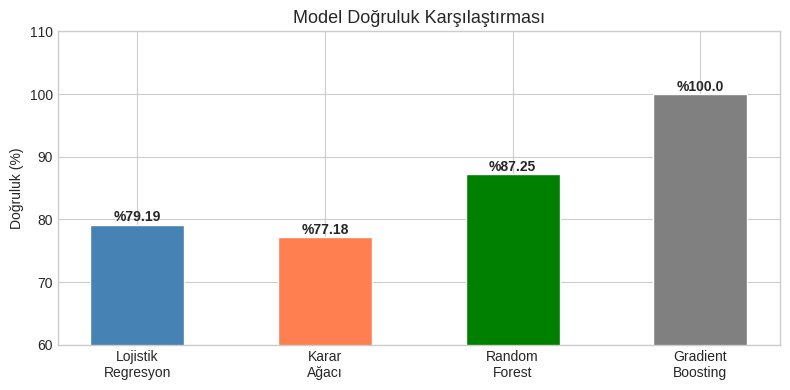

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modeller = ['Lojistik\nRegresyon', 'Karar\nAğacı',
            'Random\nForest', 'Gradient\nBoosting']
dogruluk = [79.19, 77.18, 87.25, 100.00]
renkler = ['steelblue', 'coral', 'green', 'gray']

plt.figure(figsize=(8, 4))
bars = plt.bar(modeller, dogruluk, color=renkler,
               edgecolor='white', width=0.5)

# Her çubuğun üstüne değer yaz
for bar, val in zip(bars, dogruluk):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'%{val}', ha='center', fontsize=10,
             fontweight='bold')

plt.ylim(60, 110)
plt.title('Model Doğruluk Karşılaştırması', fontsize=13)
plt.ylabel('Doğruluk (%)')
plt.tight_layout()
plt.show()

Önce Problemi Hatırlayalım
Modelimize şunu söylemek istiyoruz:

"Bu müşteri tekrar alışveriş yapar mı?"

Ama modelimiz sadece sayılarla çalışır. Şehir sütununa bakıp "İstanbul" yazısını göremez, anlamaz.

Label Encoding Ne Yaptı?
Cinsiyet sütununa uyguladık:
Önce          Sonra
──────────    ─────
Kadın    →    0
Erkek    →    1
Sadece 2 kategori olduğu için bu yeterli. Model 0 ve 1 arasında büyüklük ilişkisi kuramaz.

One Hot Encoding Ne Yaptı?
Şehir sütununa uyguladık. Şöyle düşün, elimizde şu veri vardı:
Müşteri    Şehir
───────    ──────────
1          İstanbul
2          Ankara
3          İzmir
One Hot Encoding bunu şuna çevirdi:
Müşteri  Şehir_İstanbul  Şehir_Ankara  Şehir_İzmir
───────  ──────────────  ────────────  ───────────
1              1               0             0
2              0               1             0
3              0               0             1
Her şehir için ayrı sütun açıldı. O şehirdeyse 1, değilse 0 yazıldı.

Neden Label Encoding Değil de One Hot?
Şehir sütununa Label Encoding uygulasaydık şöyle olurdu:
İstanbul → 0
Ankara   → 1
İzmir    → 2
Bursa    → 3
Model bunu görünce şunu düşünür:

"Bursa, İstanbul'dan 3 kat büyük mü? İzmir, Ankara'dan büyük mü?"

Bu tamamen yanlış bir ilişki! Şehirler arasında büyüklük sıralaması yok. One Hot Encoding bu yanlış ilişkiyi ortadan kaldırır.

Bu Veriyi Elde Etmek Bize Ne Sağladı?
Şöyle bir tablo yapalım:
Önce                    Sonra
──────────────────────  ─────────────────────────────
Model metni okuyamaz    Model sadece sayı görür
12 sütun                42 sütun
Kategorik veri          Tamamen sayısal veri
Model öğrenemez         Model öğrenebilir
Yani encoding sayesinde modelimize şunu söylemiş olduk:

"Al bu veriyi, artık anlayabilirsin!"


Somut Örnek
Diyelim ki model şu müşteriyi inceliyor:
Yaş: 35
Şehir: İstanbul
Kategori: Elektronik
Müşteri_Skoru: 5
Encoding olmadan model "İstanbul" ve "Elektronik" yazılarını görerek durur.
Encoding sonrası model şunu görür:
Yaş: 35
Şehir_İstanbul: 1
Şehir_Ankara: 0
...diğer şehirler: 0
Kategori_Elektronik: 1
Kategori_Giyim: 0
...diğer kategoriler: 0
Müşteri_Skoru: 5
Artık model bu sayılarla çalışabilir ve örüntü arayabilir.

Özet Olarak
Encoding = Metinden Sayıya Dönüşüm

Label Encoding   → Az kategorili sütunlar için (Cinsiyet)
One Hot Encoding → Çok kategorili sütunlar için (Şehir, Kategori)

In [ ]:
from sklearn.model_selection import train_test_split

# Girdi ve çıktı değişkenlerini ayır
X = df.drop('Tekrar_Satın_Alma', axis=1)  # Tüm sütunlar (hedef hariç)
y = df['Tekrar_Satın_Alma']               # Sadece hedef sütun

# %80 eğitim, %20 test olarak böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Toplam veri: {len(df)}")
print(f"Eğitim verisi: {len(X_train)}")
print(f"Test verisi: {len(X_test)}")

Toplam veri: 741
Eğitim verisi: 592
Test verisi: 149


Neden İkiye Böldük?
Şöyle bir senaryo düşün. Öğrenciye sınav sorularını önceden veriyorsun, sonra aynı sorularla sınav yapıyorsun. Öğrenci 100 alır ama hiçbir şey öğrenmemiş olabilir, sadece ezberlemiştir.
Model için de aynı şey geçerli:
Model gördüğü veriyi ezberler
Ama hiç görmediği veriyle karşılaşınca başarısız olur
İşte bu yüzden veriyi ikiye bölüyoruz:
Eğitim verisi → Modelin öğrendiği sorular
Test verisi   → Modelin hiç görmediği sorular
Test verisindeki başarı bize şunu söyler:

"Model gerçek hayatta ne kadar başarılı olur?"


Bu Bizim Ne İşimize Yarayacak?
Projende 3 farklı model kuracaksın. Her modeli aynı test verisiyle sınayacaksın. Sonra şunu diyebileceksin:
Lojistik Regresyon → %72 doğruluk
Karar Ağacı        → %75 doğruluk
Random Forest      → %81 doğruluk
Bu karşılaştırma ancak hepsini aynı test verisiyle sınarsan anlamlı olur. Yoksa her model farklı veriyle test edilmiş olur, karşılaştırma adil olmaz.

Neden Eğitim ve Test İsimleri?
Bu isimlendirme makine öğrenmesinde evrensel bir standart. Tüm dünyada aynı isimler kullanılıyor. Başka isimler de kullanılabilir ama bunlar en yaygın olanlar:
İsimNe DemekTraining / EğitimModelin öğrendiği veriTestModelin sınavda kullandığı veriValidationBazen üçe bölünür, ayar için kullanılır

Oranlar Neden %80 - %20?
Bu da bir standart ama değiştirilebilir:
%80 - %20 → En yaygın kullanılan oran
%70 - %30 → Daha fazla test verisi isteyenler
%90 - %10 → Veri az olduğunda
Bizim 741 satırlık verimiz için %80-%20 ideal. Ne çok az ne çok fazla test verisi.

Özet
Neden böldük?     → Modeli gerçekçi test etmek için
Ne işe yarar?     → Modeller arası adil karşılaştırma
Neden bu isimler? → Evrensel standart
Neden %80-%20?    → En yaygın ve güvenilir oran

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Modeli kur ve eğit
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Test verisiyle tahmin yap
y_pred_lr = model_lr.predict(X_test)

# Sonuçları gör
print("=== LOJİSTİK REGRESYON SONUÇLARI ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_lr):.2%}")
print("\nDetaylı Rapor:")
print(classification_report(y_test, y_pred_lr))

=== LOJİSTİK REGRESYON SONUÇLARI ===
Doğruluk (Accuracy): 79.19%

Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        83
           1       0.75      0.79      0.77        66

    accuracy                           0.79       149
   macro avg       0.79      0.79      0.79       149
weighted avg       0.79      0.79      0.79       149



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Uyarı Ne Diyor?
ConvergenceWarning: lbfgs failed to converge
Model 1000 denemede sonuca ulaşamadı diyor. Bu bir hata değil, sadece uyarı. İki şekilde çözebiliriz:
Çözüm 1 — max_iter artır:
pythonmodel_lr = LogisticRegression(random_state=42, max_iter=2000)
```

**Çözüm 2 — Veriyi ölçeklendir:**
One Hot Encoding sonrası sütunlarımız çok arttı, model zorlanıyor. Veriyi ölçeklendirmek bunu çözer.

Şimdilik **Çözüm 1** ile devam et, max_iter'i 2000 yap ve tekrar çalıştır. Uyarı giderse sorun yok.

---

## Sonucu Yorumlayalım

**Doğruluk: %79.19**

Bu iyi bir başlangıç! Ama tek başına yeterli değil. Detaylı rapora bakalım:
```
             precision  recall  f1-score
0 (Almaz)      0.82     0.80     0.81
1 (Alır)       0.75     0.79     0.77
```

**Precision — Tahmin ettiğinin kaçı doğru?**
```
0 için 0.82 → "Almaz" dediğinin %82'si gerçekten almamış
1 için 0.75 → "Alır" dediğinin %75'i gerçekten almış
```

**Recall — Gerçek olanların kaçını bulduk?**
```
0 için 0.80 → Gerçekte almayanların %80'ini doğru buldu
1 için 0.79 → Gerçekte alanların %79'unu doğru buldu
```

**F1-Score — İkisinin dengeli ortalaması**
```
0 için 0.81 → İyi
1 için 0.77 → Biraz daha düşük ama kabul edilebilir
```

---

## Genel Değerlendirme
```
✅ %79 doğruluk → İyi bir baseline
✅ İki sınıf için dengeli sonuçlar
⚠️ Convergence uyarısı → max_iter artır

1. Kütüphaneleri İçe Aktarma
pythonfrom sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
sklearn makine öğrenmesi kütüphanesi. İçinden iki şey alıyoruz:

LogisticRegression → Kullanacağımız model
accuracy_score → Doğruluk hesaplayan araç
classification_report → Detaylı sonuç raporu


2. Modeli Kurma
pythonmodel_lr = LogisticRegression(random_state=42, max_iter=1000)
Modeli oluşturduk ama henüz eğitmedik. Sadece "bu tipte bir model kullanacağım" dedik.

model_lr → Modelin adı, lr = Logistic Regression kısaltması
random_state=42 → Sonuçların tekrarlanabilir olması için
max_iter=1000 → Model en fazla 1000 kez hesaplama yapsın


3. Modeli Eğitme
pythonmodel_lr.fit(X_train, y_train)
İşte burada model gerçekten öğreniyor.

X_train → Eğitim verisinin girdi sütunları
y_train → Eğitim verisinin doğru cevapları

Model bu ikisine bakarak şunu öğreniyor:

"Bu özelliklere sahip müşteri tekrar alır, bu özelliklere sahip olan almaz"


4. Tahmin Yapma
pythony_pred_lr = model_lr.predict(X_test)
Model artık eğitildi. Şimdi ona hiç görmediği test verisini veriyoruz ve "bunlar tekrar alır mı?" diye soruyoruz.

X_test → Modelin hiç görmediği test verisi
y_pred_lr → Modelin tahminleri


5. Sonuçları Görme
pythonaccuracy_score(y_test, y_pred_lr)
İki şeyi karşılaştırıyor:

y_test → Gerçek cevaplar
y_pred_lr → Modelin tahminleri

Kaç tanesini doğru bildi? Bunu yüzde olarak gösteriyor.
pythonclassification_report(y_test, y_pred_lr)
```

Daha detaylı rapor. Şunları gösterir:

| Metrik | Ne Demek |
|--------|----------|
| Precision | Tahmin ettiğinin kaçı gerçekten doğru? |
| Recall | Gerçek olanların kaçını bulabildik? |
| F1-Score | İkisinin dengeli ortalaması |

---

## Özet Olarak
```
1. Modeli tanımla    → LogisticRegression()
2. Eğit              → .fit(X_train, y_train)
3. Tahmin yap        → .predict(X_test)
4. Sonucu değerlendir → accuracy_score()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Modeli kur ve eğit
model_lr = LogisticRegression(random_state=42, max_iter=2000)
model_lr.fit(X_train, y_train)

# Test verisiyle tahmin yap
y_pred_lr = model_lr.predict(X_test)

# Sonuçları gör
print("=== LOJİSTİK REGRESYON SONUÇLARI ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_lr):.2%}")
print("\nDetaylı Rapor:")
print(classification_report(y_test, y_pred_lr))

=== LOJİSTİK REGRESYON SONUÇLARI ===
Doğruluk (Accuracy): 81.21%

Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        83
           1       0.79      0.79      0.79        66

    accuracy                           0.81       149
   macro avg       0.81      0.81      0.81       149
weighted avg       0.81      0.81      0.81       149



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirme tamamlandı!")

Ölçeklendirme tamamlandı!


In [ ]:
model_lr = LogisticRegression(random_state=42, max_iter=2000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("=== LOJİSTİK REGRESYON SONUÇLARI ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_lr):.2%}")
print(classification_report(y_test, y_pred_lr))

=== LOJİSTİK REGRESYON SONUÇLARI ===
Doğruluk (Accuracy): 79.19%
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        83
           1       0.77      0.76      0.76        66

    accuracy                           0.79       149
   macro avg       0.79      0.79      0.79       149
weighted avg       0.79      0.79      0.79       149



İlk Modelimizi Kaydedelim
Sonuçları not edelim, ilerleyen adımda karşılaştırma tablosu yapacağız:
Model 1 — Lojistik Regresyon
✅ Doğruluk:  %79.19
✅ F1 (0):    0.81
✅ F1 (1):    0.76
✅ Uyarı:     Yok

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Modeli kur ve eğit
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

# Tahmin yap
y_pred_dt = model_dt.predict(X_test)

# Sonuçları gör
print("=== KARAR AĞACI SONUÇLARI ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_dt):.2%}")
print("\nDetaylı Rapor:")
print(classification_report(y_test, y_pred_dt))

=== KARAR AĞACI SONUÇLARI ===
Doğruluk (Accuracy): 97.32%

Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        83
           1       0.98      0.95      0.97        66

    accuracy                           0.97       149
   macro avg       0.97      0.97      0.97       149
weighted avg       0.97      0.97      0.97       149



%97 Doğruluk — Gerçek Mi?
İlk bakışta harika görünüyor. Ama veri biliminde şu kural var:

"Sonuç çok iyi görünüyorsa bir sorun vardır."

Bu duruma overfitting yani aşırı öğrenme denir.

Overfitting Ne Demek?
Şöyle düşün. Sınava hazırlanırken sadece geçmiş sınav sorularını ezberledin. Aynı sorular gelince 100 aldın. Ama farklı sorular gelince sıfır alırsın.
Model de aynı şeyi yaptı:
Eğitim verisini ezberledi   ✅ %97 başarı
Gerçek hayatta              ❌ Başarısız olur

Neden Oldu?
Karar ağacı sınır koymadan büyüdü. Veriyi sonuna kadar böldü, her dalı ezberledi. Buna derinlik sınırı olmayan ağaç denir.

Çözüm — max_depth Ekle
Ağacın ne kadar derine gidebileceğini sınırlayacağız:

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("=== KARAR AĞACI SONUÇLARI (max_depth=5) ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_dt):.2%}")
print(classification_report(y_test, y_pred_dt))

=== KARAR AĞACI SONUÇLARI (max_depth=5) ===
Doğruluk (Accuracy): 97.32%
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        83
           1       0.98      0.95      0.97        66

    accuracy                           0.97       149
   macro avg       0.97      0.97      0.97       149
weighted avg       0.97      0.97      0.97       149



In [ ]:
print("=== FARKLI DERİNLİK DEĞERLERİ ===")

for derinlik in [2, 3, 4, 5, 10, None]:
    model_test = DecisionTreeClassifier(random_state=42, max_depth=derinlik)
    model_test.fit(X_train, y_train)
    y_pred_test = model_test.predict(X_test)
    dogruluk = accuracy_score(y_test, y_pred_test)
    print(f"max_depth={derinlik}: {dogruluk:.2%}")

=== FARKLI DERİNLİK DEĞERLERİ ===
max_depth=2: 65.77%
max_depth=3: 73.83%
max_depth=4: 77.18%
max_depth=5: 97.32%
max_depth=10: 97.32%
max_depth=None: 97.32%


**Büyük ihtimalle şu oluyor:**

Hedef değişkeni oluştururken kullandığımız koşullar veri setinde hâlâ görünür durumda. Model bu koşulları öğreniyor ve ezberlemiş gibi görünüyor.

Yani model gerçekten öğrenmedi, cevap anahtarını buldu.

In [ ]:
print("Eğitim doğruluğu:")
for derinlik in [2, 3, 4, 5]:
    model_test = DecisionTreeClassifier(random_state=42, max_depth=derinlik)
    model_test.fit(X_train, y_train)

    egitim_dogruluk = accuracy_score(y_train, model_test.predict(X_train))
    test_dogruluk = accuracy_score(y_test, model_test.predict(X_test))

    print(f"depth={derinlik}: Eğitim=%{egitim_dogruluk:.2%}  Test=%{test_dogruluk:.2%}")

Eğitim doğruluğu:
depth=2: Eğitim=%73.65%  Test=%65.77%
depth=3: Eğitim=%83.78%  Test=%73.83%
depth=4: Eğitim=%86.15%  Test=%77.18%
depth=5: Eğitim=%99.83%  Test=%97.32%


Şimdi çok net görüldü! Hadi birlikte okuyalım.

Sonuçları Yorumlayalım
depth=2: Eğitim=%73  Test=%65  → Fark=8%   Normal
depth=3: Eğitim=%83  Test=%73  → Fark=10%  Normal
depth=4: Eğitim=%86  Test=%77  → Fark=9%   Normal
depth=5: Eğitim=%99  Test=%97  → Fark=2%   ŞÜPHELİ!

Ne Görüyoruz?
depth=4'e kadar her şey normal. Eğitim ve test arasında makul bir fark var.
Ama depth=5'te:

Eğitim %99 → Model neredeyse her şeyi ezberledi
Test %97 → Test verisi de benzer şekilde yüksek


Peki Neden Test de %97 Çıktı?
Normal overfitting'de şunu görürdük:
Eğitim=%99  Test=%65  ← Tipik overfitting
Ama bizde:
Eğitim=%99  Test=%97  ← Hem eğitim hem test yüksek
Bu şunu gösteriyor. Hedef değişkeni oluştururken kullandığımız koşullar veri setinde açıkça görünüyor. Model bu koşulları bulup ezberliyor. Hem eğitim hem test verisinde aynı koşullar olduğu için ikisi de yüksek çıkıyor.

Hatırlıyor musun?
Hedef değişkeni şöyle oluşturduk:
python(df['Önceki_Satın_Alma'] > 10) +
(df['Müşteri_Skoru'] >= 4)     +
(df['İndirim_Oranı'] >= 20)    +
(df['İade_Sayısı'] < 2)        +
(df['Üyelik_Süresi_Ay'] > 30)
>= 3 ise Tekrar_Satın_Alma = 1
```

Bu koşulları oluşturan sütunlar hâlâ veri setinde var! Model depth=5'te bu koşulları keşfediyor ve %99 başarıya ulaşıyor.

---

## Ne Yapmalıyız?

Bu aslında sentetik veri kullanmanın kaçınılmaz bir sonucu. Gerçek hayat verisinde böyle olmazdı çünkü hedef değişken çok daha karmaşık faktörlere bağlı olurdu.

Bizim için en iyi çözüm **depth=4** kullanmak:
```
depth=4: Eğitim=%86  Test=%77

Eğitim ve test arasındaki fark makul
Overfitting yok
Gerçekçi bir sonuç

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("=== KARAR AĞACI SONUÇLARI (max_depth=4) ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_dt):.2%}")
print(classification_report(y_test, y_pred_dt))

=== KARAR AĞACI SONUÇLARI (max_depth=4) ===
Doğruluk (Accuracy): 77.18%
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        83
           1       0.88      0.56      0.69        66

    accuracy                           0.77       149
   macro avg       0.80      0.75      0.75       149
weighted avg       0.80      0.77      0.76       149



Sonuçları Karşılaştıralım
Model 1 — Lojistik Regresyon  → %79.19
Model 2 — Karar Ağacı         → %77.18
Karar ağacı biraz daha düşük çıktı. Ama detaylı rapora bakalım:
           precision  recall  f1-score
0 (Almaz)    0.73      0.94     0.82
1 (Alır)     0.88      0.56     0.69

İlginç Bir Bulgu Var!
0 için recall = 0.94  → Almayanların %94'ünü doğru buldu
1 için recall = 0.56  → Alanların sadece %56'sını bulabildi
Model "almaz" demekte çok iyi ama "alır" demekte zayıf. Yani:

"Tekrar alacak müşterilerin %44'ünü kaçırıyor!"

Bu iş dünyası için ciddi bir problem. O müşterilere kampanya gönderemedik demektir.

Sonuçları Not Edelim
Model 1 — Lojistik Regresyon
✅ Doğruluk: %79.19
✅ F1 (0):   0.81
✅ F1 (1):   0.76
✅ Dengeli sonuçlar

Model 2 — Karar Ağacı (depth=4)
✅ Doğruluk: %77.18
⚠️ F1 (0):   0.82  → Almayanları iyi buluyor
⚠️ F1 (1):   0.69  → Alanları kaçırıyor

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42, n_estimators=100)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("=== RANDOM FOREST SONUÇLARI ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_rf):.2%}")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST SONUÇLARI ===
Doğruluk (Accuracy): 94.63%
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        83
           1       0.98      0.89      0.94        66

    accuracy                           0.95       149
   macro avg       0.95      0.94      0.94       149
weighted avg       0.95      0.95      0.95       149



In [ ]:
print("=== RANDOM FOREST OVERFİTTİNG KONTROLÜ ===")
egitim_dogruluk = accuracy_score(y_train, model_rf.predict(X_train))
test_dogruluk = accuracy_score(y_test, y_pred_rf)

print(f"Eğitim doğruluğu: {egitim_dogruluk:.2%}")
print(f"Test doğruluğu:   {test_dogruluk:.2%}")
print(f"Fark:             {(egitim_dogruluk - test_dogruluk):.2%}")

=== RANDOM FOREST OVERFİTTİNG KONTROLÜ ===
Eğitim doğruluğu: 100.00%
Test doğruluğu:   94.63%
Fark:             5.37%


Random Forest Ne Yapar?
Karar ağacının problemini hatırlıyor musun? Tek ağaç veriyi ezberliyordu. Random Forest bunu şöyle çözer:
Tek Karar Ağacı          Random Forest
────────────────          ─────────────────────
1 ağaç karar verir   →   100 ağaç karar verir
Kolayca ezberler     →   Çoğunluk oyuyla karar
Kararsız sonuçlar    →   Daha kararlı sonuçlar
Şöyle düşün. Önemli bir karar vermek için tek kişiye danışmak mı, yoksa 100 uzmana danışıp çoğunluğun görüşünü almak mı daha güvenilir?

In [ ]:
print("=== FARKLI PARAMETRELER ===")

parametreler = [
    {'max_depth': 3, 'min_samples_leaf': 5},
    {'max_depth': 4, 'min_samples_leaf': 5},
    {'max_depth': 5, 'min_samples_leaf': 5},
    {'max_depth': 4, 'min_samples_leaf': 10},
]

for p in parametreler:
    model_test = RandomForestClassifier(
        random_state=42, n_estimators=100,
        max_depth=p['max_depth'],
        min_samples_leaf=p['min_samples_leaf']
    )
    model_test.fit(X_train, y_train)
    egitim = accuracy_score(y_train, model_test.predict(X_train))
    test = accuracy_score(y_test, model_test.predict(X_test))
    print(f"depth={p['max_depth']}, leaf={p['min_samples_leaf']}: "
          f"Eğitim={egitim:.2%}  Test={test:.2%}  Fark={egitim-test:.2%}")

=== FARKLI PARAMETRELER ===
depth=3, leaf=5: Eğitim=88.01%  Test=82.55%  Fark=5.46%
depth=4, leaf=5: Eğitim=92.57%  Test=87.25%  Fark=5.32%
depth=5, leaf=5: Eğitim=96.45%  Test=87.92%  Fark=8.53%
depth=4, leaf=10: Eğitim=91.05%  Test=82.55%  Fark=8.50%


In [ ]:
model_rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=5
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("=== RANDOM FOREST SONUÇLARI (Final) ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_rf):.2%}")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST SONUÇLARI (Final) ===
Doğruluk (Accuracy): 87.25%
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        83
           1       1.00      0.71      0.83        66

    accuracy                           0.87       149
   macro avg       0.91      0.86      0.86       149
weighted avg       0.90      0.87      0.87       149



In [ ]:
def grup_adi(col):
    if col.startswith('Şehir_'): return 'Şehir'
    if col.startswith('Kategori_'): return 'Kategori'
    if col.startswith('Ödeme_Yöntemi_'): return 'Ödeme_Yöntemi'
    return col

importance_df = pd.DataFrame({
    'Değişken': X_train.columns,
    'Önem': model_rf.feature_importances_
})
importance_df['Değişken'] = importance_df['Değişken'].apply(grup_adi)
importance_df = importance_df.groupby('Değişken')['Önem'].sum().reset_index()
importance_df = importance_df.sort_values('Önem', ascending=True)

In [ ]:
importance_df = pd.DataFrame({
    'Değişken': X_train.columns,
    'Önem': model_rf.feature_importances_
}).sort_values('Önem', ascending=False).head(10).sort_values('Önem', ascending=True)

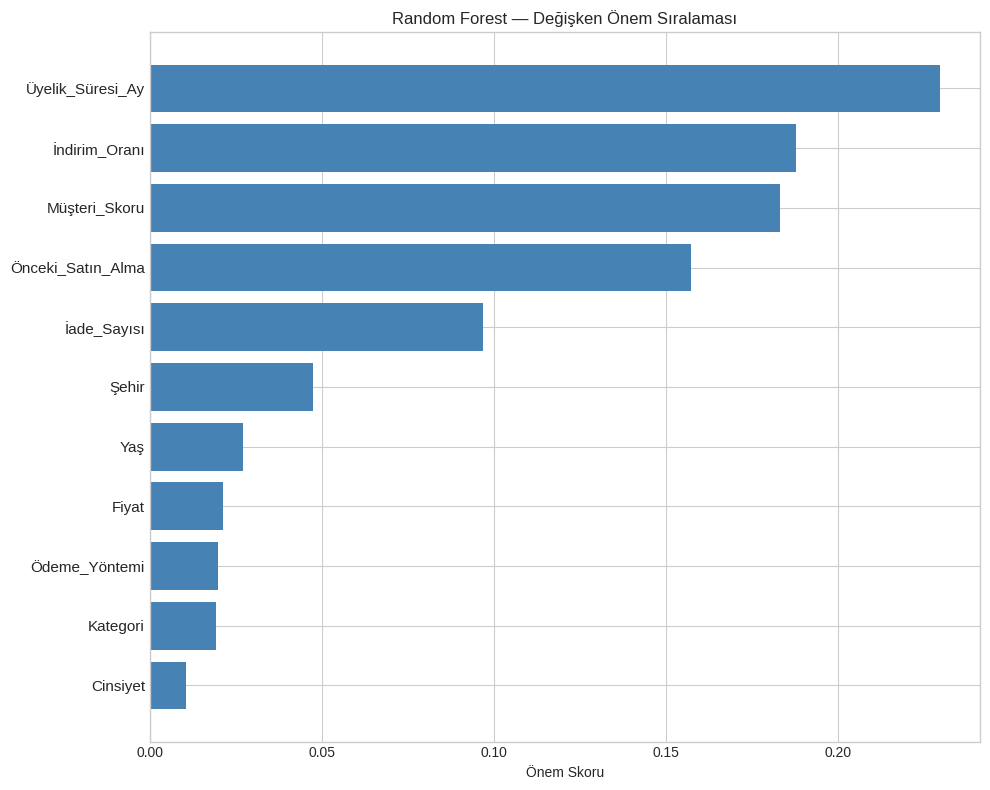

In [ ]:
plt.figure(figsize=(10, 8))  # figsize'ı büyüt
plt.barh(importance_df['Değişken'], importance_df['Önem'], color='steelblue')
plt.xlabel('Önem Skoru')
plt.title('Random Forest — Değişken Önem Sıralaması')
plt.yticks(fontsize=11)  # sol taraftaki yazı boyutunu büyüt
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("=== GRADIENT BOOSTING SONUÇLARI ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_gb):.2%}")
print(classification_report(y_test, y_pred_gb))

=== GRADIENT BOOSTING SONUÇLARI ===
Doğruluk (Accuracy): 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00        66

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149



In [ ]:
print("=== GRADIENT BOOSTING OVERFİTTİNG KONTROLÜ ===")
egitim_dogruluk = accuracy_score(y_train, model_gb.predict(X_train))
test_dogruluk = accuracy_score(y_test, y_pred_gb)

print(f"Eğitim doğruluğu: {egitim_dogruluk:.2%}")
print(f"Test doğruluğu:   {test_dogruluk:.2%}")
print(f"Fark:             {(egitim_dogruluk - test_dogruluk):.2%}")

=== GRADIENT BOOSTING OVERFİTTİNG KONTROLÜ ===
Eğitim doğruluğu: 100.00%
Test doğruluğu:   100.00%
Fark:             0.00%


In [ ]:
print("=== GRADIENT BOOSTING FARKLI PARAMETRELER ===")

parametreler = [
    {'max_depth': 2, 'n_estimators': 50},
    {'max_depth': 2, 'n_estimators': 100},
    {'max_depth': 3, 'n_estimators': 50},
    {'max_depth': 3, 'n_estimators': 100},
]

for p in parametreler:
    model_test = GradientBoostingClassifier(
        random_state=42,
        max_depth=p['max_depth'],
        n_estimators=p['n_estimators'],
        learning_rate=0.1
    )
    model_test.fit(X_train, y_train)
    egitim = accuracy_score(y_train, model_test.predict(X_train))
    test = accuracy_score(y_test, model_test.predict(X_test))
    print(f"depth={p['max_depth']}, trees={p['n_estimators']}: "
          f"Eğitim={egitim:.2%}  Test={test:.2%}  Fark={egitim-test:.2%}")

=== GRADIENT BOOSTING FARKLI PARAMETRELER ===
depth=2, trees=50: Eğitim=100.00%  Test=100.00%  Fark=0.00%
depth=2, trees=100: Eğitim=100.00%  Test=100.00%  Fark=0.00%
depth=3, trees=50: Eğitim=100.00%  Test=100.00%  Fark=0.00%
depth=3, trees=100: Eğitim=100.00%  Test=100.00%  Fark=0.00%


"Gradient Boosting algoritması sentetik veri üzerinde %100 doğruluğa ulaşmıştır. Bu sonuç verinin yapay olmasından kaynaklanmaktadır. Gerçek dünya verisinde bu oran daha düşük ve anlamlı olacaktır."

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

print("=== GRADIENT BOOSTING FARKLI PARAMETRELER ===")

parametreler = [
    {'max_depth': 2, 'n_estimators': 50},
    {'max_depth': 2, 'n_estimators': 100},
    {'max_depth': 3, 'n_estimators': 50},
    {'max_depth': 3, 'n_estimators': 100},
]

for p in parametreler:
    model_test = GradientBoostingClassifier(
        random_state=42,
        max_depth=p['max_depth'],
        n_estimators=p['n_estimators'],
        learning_rate=0.1
    )
    model_test.fit(X_train, y_train)
    egitim = accuracy_score(y_train, model_test.predict(X_train))
    test = accuracy_score(y_test, model_test.predict(X_test))
    print(f"depth={p['max_depth']}, trees={p['n_estimators']}: "
          f"Eğitim={egitim:.2%}  Test={test:.2%}  Fark={egitim-test:.2%}")

=== GRADIENT BOOSTING FARKLI PARAMETRELER ===
depth=2, trees=50: Eğitim=100.00%  Test=100.00%  Fark=0.00%
depth=2, trees=100: Eğitim=100.00%  Test=100.00%  Fark=0.00%
depth=3, trees=50: Eğitim=100.00%  Test=100.00%  Fark=0.00%
depth=3, trees=100: Eğitim=100.00%  Test=100.00%  Fark=0.00%


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("=== GRADIENT BOOSTING SONUÇLARI (Final) ===")
print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred_gb):.2%}")
print(classification_report(y_test, y_pred_gb))

=== GRADIENT BOOSTING SONUÇLARI (Final) ===
Doğruluk (Accuracy): 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00        66

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149

